## Step 1: Import Libraries

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import layers, models

## Step 2: Define Constants

In [ ]:
SAMPLE_RATE = 22050
DURATION = 5
SAMPLES = SAMPLE_RATE * DURATION
N_MELS = 128

CLASS_NAMES = ["asthma", "copd", "bronchial", "pneumonia", "healthy"]
NUM_CLASSES = len(CLASS_NAMES)

### Step 3: Audio Preprocessing Function

In [ ]:


def preprocess_audio(file_path, augment=False):

    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # Fix length
    if len(signal) > SAMPLES:
        signal = signal[:SAMPLES]
    else:
        signal = np.pad(signal, (0, SAMPLES - len(signal)))

    # ✅ AUDIO AUGMENTATION
    if augment:
        # Random noise
        noise = np.random.randn(len(signal))
        signal = signal + 0.005 * noise

        # Time shift
        shift = np.random.randint(SAMPLE_RATE)
        signal = np.roll(signal, shift)

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        fmax=8000
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ✅ Add delta features (VERY IMPORTANT)
    delta = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    # Stack → (128, time, 3)
    feature = np.stack([mel_db, delta, delta2], axis=-1)

    # Normalize
    feature = (feature - np.mean(feature)) / (np.std(feature) + 1e-6)

    return feature

### Step 4: Load Dataset

In [ ]:


def load_dataset(path):

    X, y = [], []

    for label, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(path, cls)

        for file in os.listdir(folder):
            if file.endswith(".wav"):
                file_path = os.path.join(folder, file)

                try:
                    # Original
                    X.append(preprocess_audio(file_path, augment=False))
                    y.append(label)

                    # Augmented copy
                    X.append(preprocess_audio(file_path, augment=True))
                    y.append(label)

                except:
                    print("Error loading:", file)

    return np.array(X), np.array(y)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir("."))

Current working directory: /content
Files in current directory: ['.config', 'drive', 'sample_data']


In [7]:

DATASET_PATH = "/content/drive/MyDrive/datasets/Audio_Detection_Dataset/"
X, y = load_dataset(DATASET_PATH)

X = X[..., np.newaxis]  # add channel




# Step 6: Visualization Functions

## Class distribution

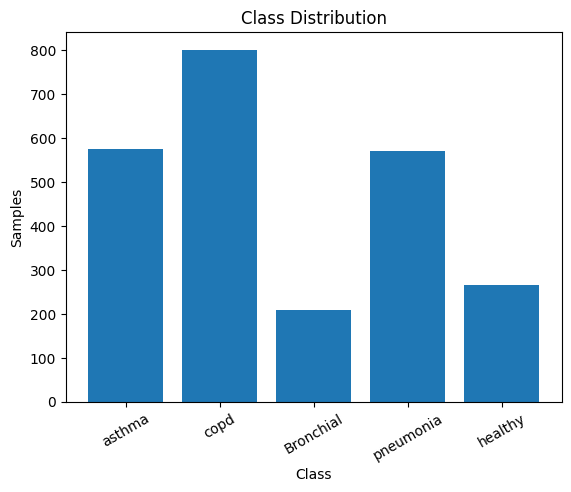

In [ ]:

def plot_class_distribution(y, class_names):
    counts = np.bincount(y)
    
    plt.figure()
    plt.bar(class_names, counts)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Samples")
    plt.xticks(rotation=30)
    plt.show()
plot_class_distribution(y,CLASS_NAMES)

## Sample spectrogram visualization

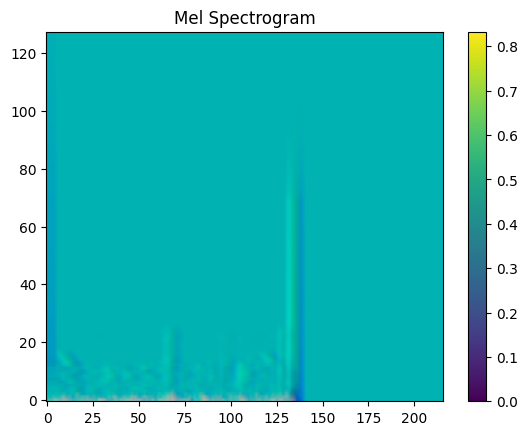

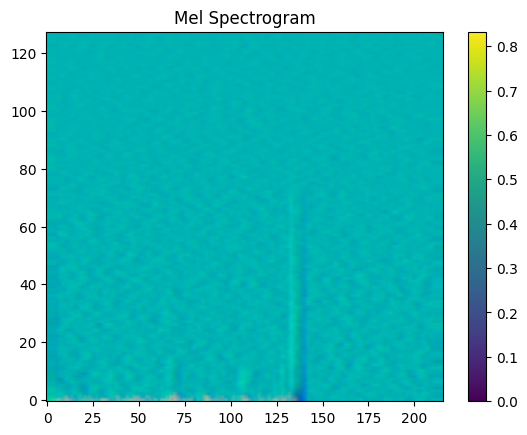

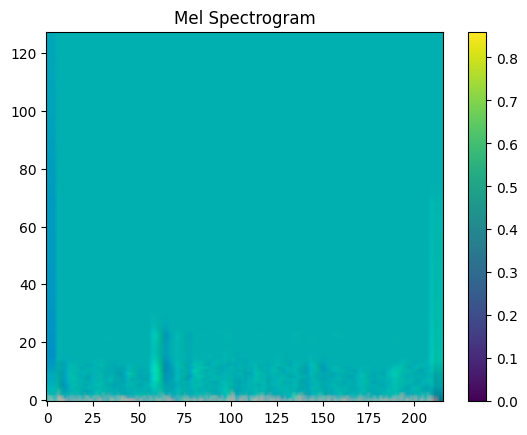

In [40]:
def show_spectrogram(sample):
    plt.figure()
    plt.imshow(sample.squeeze(), aspect='auto', origin='lower')
    plt.title("Mel Spectrogram")
    plt.colorbar()
    plt.show()
for i in range(3):
    show_spectrogram(X[i])

## Step 8: Train-Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


y_train = to_categorical(y_train, num_classes=5)
y_val = to_categorical(y_val, num_classes=5)

### Handle Class Imbalance

## Step 9: Build CNN Model

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model():

    inputs = layers.Input(shape=(128, 216, 3))

    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # ✅ Global pooling (reduces overfitting)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(5, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model
model=build_model()

In [10]:


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 216, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 13, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        patience=15,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

In [12]:
print(y_train.shape)
print(y_val.shape)

(1937, 5)
(485, 5)


## Step 10: Train Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7124 - loss: 0.9842 - val_accuracy: 0.7299 - val_loss: 0.9894 - learning_rate: 1.0000e-04
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7300 - loss: 0.9550 - val_accuracy: 0.7567 - val_loss: 0.9531 - learning_rate: 1.0000e-04
Epoch 3/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7512 - loss: 0.9183 - val_accuracy: 0.6371 - val_loss: 1.1486 - learning_rate: 1.0000e-04
Epoch 4/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7450 - loss: 0.9092 - val_accuracy: 0.6928 - val_loss: 1.0280 - learning_rate: 1.0000e-04
Epoch 5/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7558 - loss: 0.8867 - val_accuracy: 0.7402 - val_loss: 0.9478 - learning_rate: 1.0000e-04
Epoch 6/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7832 - loss: 0.8571 - val_accuracy: 0.7918 - val_loss: 0.8482 - learning_rate: 1.0000e-04
Epoch 7/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - acc

## Step 11: Predictions

In [56]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


# Step 12: Model evaluation

## confusion matrix

In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred = np.argmax(model.predict(X_val), axis=1)

# Convert one-hot → labels
y_true = np.argmax(y_val, axis=1)

# Confusion Matrix
print(confusion_matrix(y_true, y_pred))

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[108   3   0   1   3]
 [  3 154   2   2   0]
 [  8   0  33   0   1]
 [ 12   1   0  95   6]
 [  0   3   0   3  47]]
              precision    recall  f1-score   support

      asthma       0.82      0.94      0.88       115
        copd       0.96      0.96      0.96       161
   Bronchial       0.94      0.79      0.86        42
   pneumonia       0.94      0.83      0.88       114
     healthy       0.82      0.89      0.85        53

    accuracy                           0.90       485
   macro avg       0.90      0.88      0.89       485
weighted avg       0.91      0.90      0.90       485



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


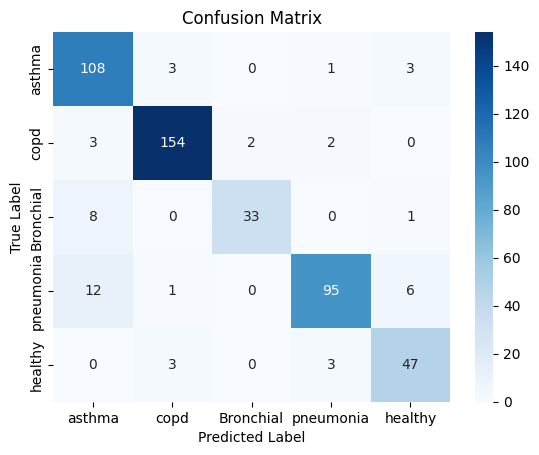

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

class_names = ['asthma', 'copd', 'Bronchial', 'pneumonia', 'healthy']

plot_confusion_matrix(y_true, y_pred, class_names)

## Training Curves

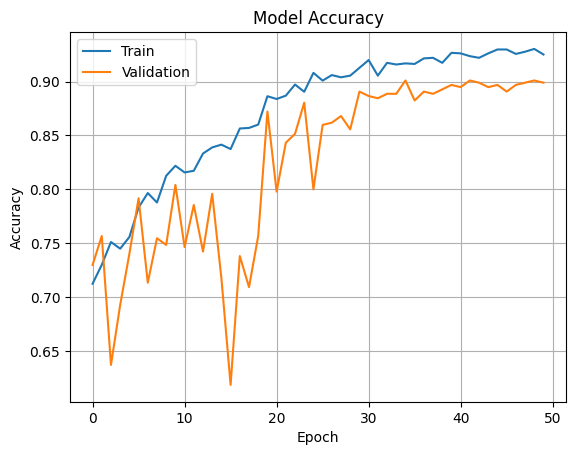

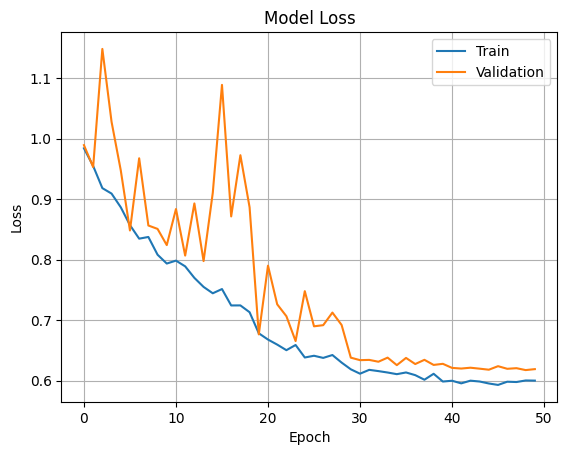

In [46]:
def plot_training(history):

    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.grid()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])
    plt.grid()
    plt.show()
plot_training(history)

In [47]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## Misclassified Samples

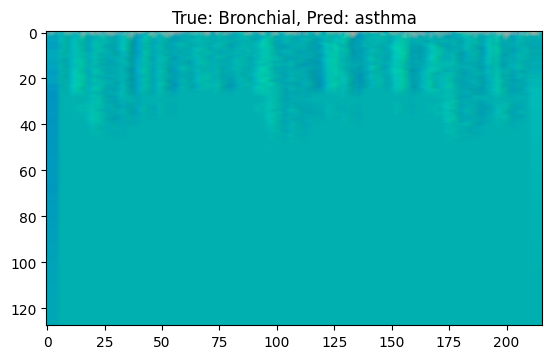

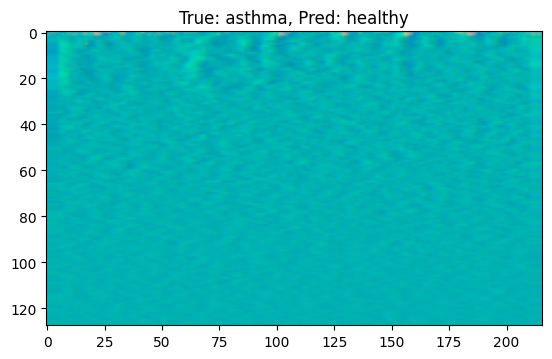

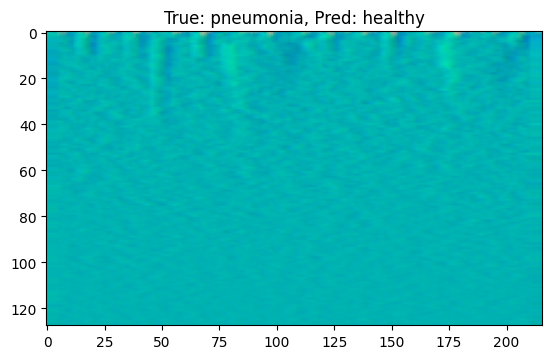

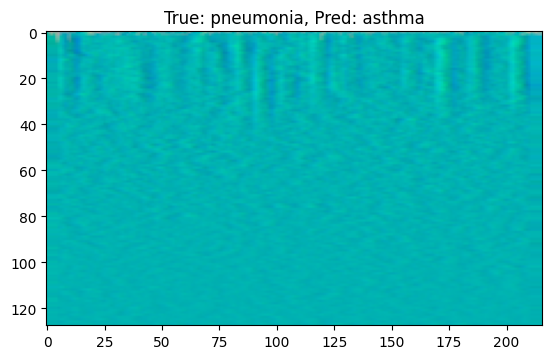

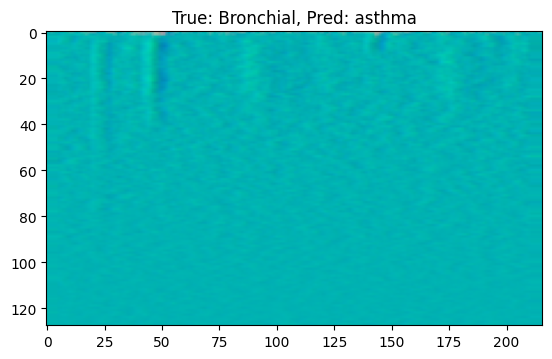

In [48]:
def show_errors(X_val, y_true, y_pred, class_names):
    wrong = np.where(y_true != y_pred)[0]

    for i in wrong[:5]:
        plt.imshow(X_val[i].squeeze())
        plt.title(f"True: {class_names[y_true[i]]}, Pred: {class_names[y_pred[i]]}")
        plt.show()

show_errors(X_val, y_true, y_pred, class_names)

## ROC Curve

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


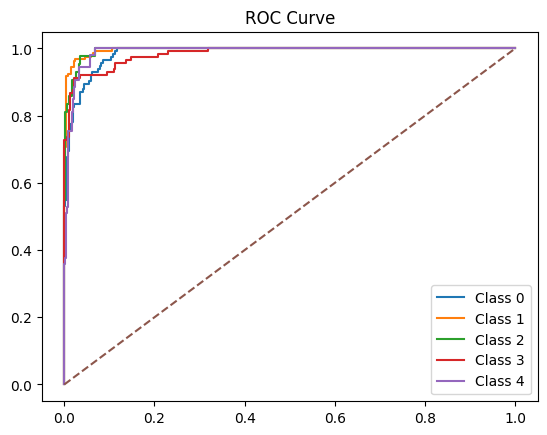

In [ ]:
def plot_roc(model, X_val, y_val, n_classes):
    y_score = model.predict(X_val)
    y_val_bin = label_binarize(np.argmax(y_val, axis=1), classes=range(n_classes))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()
plot_roc(model, X_val, y_val, n_classes=5)

## Precision-Recall Curve

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


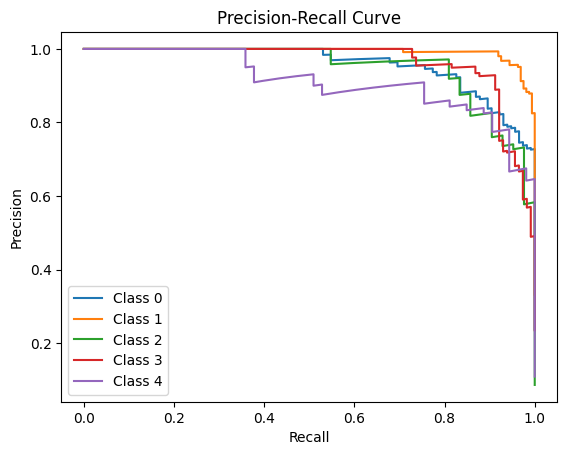

In [50]:
def plot_pr_curve(model, X_val, y_val, n_classes):
    y_score = model.predict(X_val)

    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_val[:, i], y_score[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.title("Precision-Recall Curve")
    plt.show()


plot_pr_curve(model, X_val, y_val, 5)

## Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


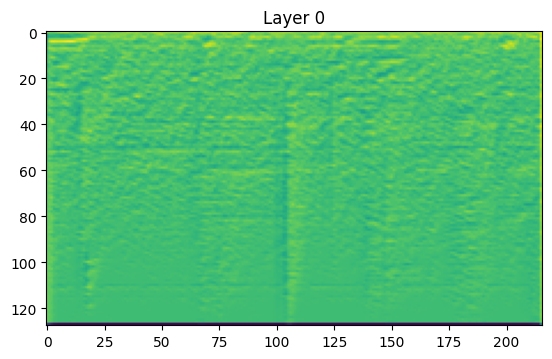

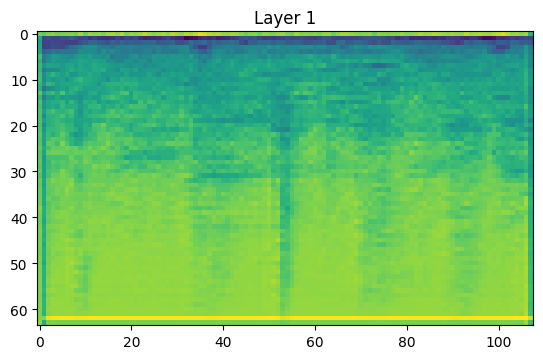

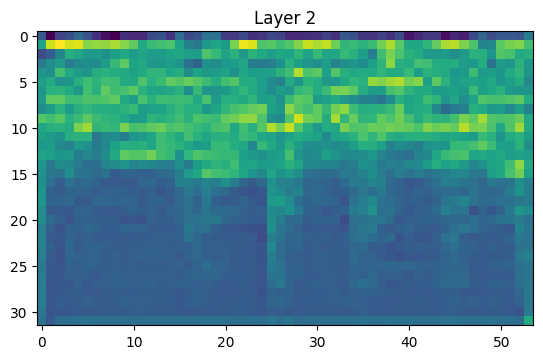

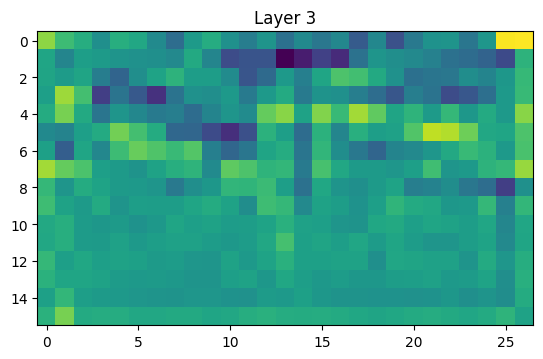

In [51]:
from tensorflow.keras.models import Model

def visualize_feature_maps(model, sample):
    layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]
    activation_model = Model(inputs=model.input, outputs=layer_outputs)

    activations = activation_model.predict(sample[np.newaxis,...])

    for i, activation in enumerate(activations):
        plt.figure()
        plt.imshow(activation[0,:,:,0])
        plt.title(f"Layer {i}")
        plt.show()
visualize_feature_maps(model, X_val[0])

## Save model and preprocessing config

In [60]:
# ===============================
# ✅ STEP 1: Save trained model
# ===============================
model.save("lung_model.keras")


# ===============================
# ✅ STEP 2: Compute dataset stats (IMPORTANT)
# ===============================
# Use TRAINING data only
mean = float(np.mean(X_train))
std = float(np.std(X_train))


# ===============================
# ✅ STEP 3: Save full preprocessing config
# ===============================
import json

config = {
    # Audio settings
    "sample_rate": SAMPLE_RATE,
    "duration": DURATION,
    "samples": SAMPLES,

    # Spectrogram settings
    "n_mels": N_MELS,
    "fmax": 8000,

    # Feature engineering
    "use_delta": True,
    "delta_order": 2,

    # Normalization (CRITICAL)
    "mean": mean,
    "std": std,

    # Classes
    "classes": CLASS_NAMES
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)


# ===============================
# ✅ STEP 4: Confirmation logs
# ===============================
print("✅ Model saved as: lung_model.keras")
print("✅ Config saved as: config.json")
print(f"📊 Mean: {mean:.4f}, Std: {std:.4f}")

✅ Model saved as: lung_model.keras
✅ Config saved as: config.json
📊 Mean: 0.0000, Std: 1.0000


In [63]:
import os

SAVE_DIR = "../Backend"   # adjust if needed
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "lung_model.keras"))

with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("✅ Saved to Backend folder")

✅ Saved to Backend folder


In [62]:
import os
print(os.getcwd())

/content
